# Stage 8: Simulation Results

This notebook summarizes Stage 8 outputs from `results/simulation` for the available feature-selection methods.

It includes:
- data coverage and schema checks
- numeric summary tables (recall/FDR)
- plots by signal type, effect size, and top-k setting

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "results" / "simulation").exists() and (candidate / "src").exists():
            return candidate
    return start


ROOT = find_repo_root(Path.cwd())
RESULTS_ROOT = ROOT / "results" / "simulation"
METHODS = ["ttest", "random"]

recall_frames = []
fdr_frames = []
meta_rows = []

for method in METHODS:
    recall_path = RESULTS_ROOT / method / "recall.parquet"
    fdr_path = RESULTS_ROOT / method / "fdr.parquet"
    meta_path = RESULTS_ROOT / method / "meta.json"

    if not recall_path.exists() or not fdr_path.exists():
        print(f"[WARN] Missing recall/fdr parquet for method='{method}' under {RESULTS_ROOT / method}")
        continue

    recall_method = pd.read_parquet(recall_path).copy()
    recall_method["method"] = method
    recall_frames.append(recall_method)

    fdr_method = pd.read_parquet(fdr_path).copy()
    fdr_method["method"] = method
    fdr_frames.append(fdr_method)

    if meta_path.exists():
        meta = json.loads(meta_path.read_text(encoding="utf-8"))
        meta_rows.append(
            {
                "method": method,
                "n_recall_rows_meta": meta.get("n_recall_rows"),
                "n_fdr_rows_meta": meta.get("n_fdr_rows"),
                "n_repeats": meta.get("n_repeats"),
                "n_features": meta.get("n_features"),
                "signals_per_type": meta.get("signals_per_type"),
                "block_size": meta.get("block_size"),
                "effect_sizes": ", ".join(map(str, meta.get("effect_sizes", []))),
                "topk_values": ", ".join(map(str, meta.get("topk_values", []))),
                "includes_native": meta.get("includes_native"),
                "runtime_seconds": meta.get("runtime_seconds"),
            }
        )

if not recall_frames or not fdr_frames:
    raise FileNotFoundError(f"No simulation result files found under {RESULTS_ROOT}")

recall_df = pd.concat(recall_frames, ignore_index=True)
fdr_df = pd.concat(fdr_frames, ignore_index=True)
recall_df["k"] = recall_df["k"].astype(str)
fdr_df["k"] = fdr_df["k"].astype(str)

# Pre-block-structure parquets lack these columns; fill with NaN so block-metric
# cells degrade gracefully instead of raising KeyError.
if "block_recall" not in recall_df.columns:
    recall_df["block_recall"] = np.nan
if "block_fdr" not in fdr_df.columns:
    fdr_df["block_fdr"] = np.nan
HAS_BLOCK_RECALL = recall_df["block_recall"].notna().any()
HAS_BLOCK_FDR = fdr_df["block_fdr"].notna().any()

k_order = ["10", "25", "50", "100", "native"]
signal_order = ["linear", "bounded_variance", "threshold", "u_shape", "xor_pair"]

recall_df["k"] = pd.Categorical(recall_df["k"], categories=k_order, ordered=True)
recall_df["signal_type"] = pd.Categorical(recall_df["signal_type"], categories=signal_order, ordered=True)
fdr_df["k"] = pd.Categorical(fdr_df["k"], categories=k_order, ordered=True)

print(f"Detected project root: {ROOT}")
print(f"Loaded recall rows: {len(recall_df):,} | fdr rows: {len(fdr_df):,}")
print(f"block_recall present: {HAS_BLOCK_RECALL} | block_fdr present: {HAS_BLOCK_FDR}")
recall_df.head()

Detected project root: c:\Programmering\exjobb\MSc26_Proteomics
Loaded recall rows: 7,500 | fdr rows: 500
block_recall present: True | block_fdr present: True


,repeat,signal_type,effect_size,k,recall,block_recall,method
0,1,bounded_variance,0.3,10,0.0,0.0,ttest
1,1,bounded_variance,0.3,100,0.0,0.0,ttest
2,1,bounded_variance,0.3,25,0.0,0.0,ttest
3,1,bounded_variance,0.3,50,0.0,0.0,ttest
4,1,bounded_variance,0.3,native,0.0,0.0,ttest


In [2]:
meta_df = pd.DataFrame(meta_rows).set_index("method") if meta_rows else pd.DataFrame()

recall_coverage = (
    recall_df.groupby("method", observed=False)
    .agg(
        n_rows=("repeat", "size"),
        repeats=("repeat", "nunique"),
        signal_types=("signal_type", "nunique"),
        effect_sizes=("effect_size", "nunique"),
        k_values=("k", "nunique"),
    )
    .sort_index()
)

fdr_coverage = (
    fdr_df.groupby("method", observed=False)
    .agg(
        n_rows=("repeat", "size"),
        repeats=("repeat", "nunique"),
        k_values=("k", "nunique"),
    )
    .sort_index()
)

print("Meta summary")
display(meta_df)

print("Observed recall coverage")
display(recall_coverage)

print("Observed fdr coverage")
display(fdr_coverage)

if not meta_df.empty:
    compare = recall_coverage[["n_rows"]].rename(columns={"n_rows": "recall_n_rows"})
    compare["recall_n_rows_meta"] = meta_df["n_recall_rows_meta"]
    compare["fdr_n_rows"] = fdr_coverage["n_rows"]
    compare["fdr_n_rows_meta"] = meta_df["n_fdr_rows_meta"]
    compare["recall_matches"] = compare["recall_n_rows"] == compare["recall_n_rows_meta"]
    compare["fdr_matches"] = compare["fdr_n_rows"] == compare["fdr_n_rows_meta"]
    print("Row count validation")
    display(compare)

Meta summary


,n_recall_rows_meta,n_fdr_rows_meta,n_repeats,n_features,signals_per_type,block_size,effect_sizes,topk_values,includes_native,runtime_seconds
method,,,,,,,,,,
ttest,3750,250,50,11000,3,20,"0.3, 0.6, 1.0","10, 25, 50, 100",True,117.963305
random,3750,250,50,11000,3,20,"0.3, 0.6, 1.0","10, 25, 50, 100",True,113.790987


Observed recall coverage


,n_rows,repeats,signal_types,effect_sizes,k_values
method,,,,,
random,3750,50,5,3,5
ttest,3750,50,5,3,5


Observed fdr coverage


,n_rows,repeats,k_values
method,,,
random,250,50,5
ttest,250,50,5


Row count validation


,recall_n_rows,recall_n_rows_meta,fdr_n_rows,fdr_n_rows_meta,recall_matches,fdr_matches
method,,,,,,
random,3750,3750,250,250,True,True
ttest,3750,3750,250,250,True,True


In [3]:
recall_summary_method_k = (
    recall_df.groupby(["method", "k"], observed=False)
    .agg(recall_mean=("recall", "mean"), recall_std=("recall", "std"))
    .reset_index()
    .round(3)
)

fdr_summary_method_k = (
    fdr_df.groupby(["method", "k"], observed=False)
    .agg(
        fdr_mean=("fdr", "mean"),
        fdr_std=("fdr", "std"),
        n_selected_mean=("n_selected", "mean"),
    )
    .reset_index()
    .round(3)
)

print("Recall mean/SD by method and k")
display(recall_summary_method_k)
print("Recall mean pivot (k x method)")
display(recall_summary_method_k.pivot(index="k", columns="method", values="recall_mean"))

print("FDR mean/SD by method and k")
display(fdr_summary_method_k)
print("FDR mean pivot (k x method)")
display(fdr_summary_method_k.pivot(index="k", columns="method", values="fdr_mean"))

Recall mean/SD by method and k


,method,k,recall_mean,recall_std
0,random,10,0.002,0.022
1,random,25,0.003,0.029
2,random,50,0.006,0.043
3,random,100,0.010,0.054
4,random,native,0.003,0.029
5,ttest,10,0.138,0.331
6,ttest,25,0.163,0.339
7,ttest,50,0.179,0.348
8,ttest,100,0.200,0.358
9,ttest,native,0.109,0.289


Recall mean pivot (k x method)


method,random,ttest
k,,
10,0.002,0.138
25,0.003,0.163
50,0.006,0.179
100,0.010,0.200
native,0.003,0.109


FDR mean/SD by method and k


,method,k,fdr_mean,fdr_std,n_selected_mean
0,random,10,0.992,0.027,10.00
1,random,25,0.994,0.015,25.00
2,random,50,0.993,0.011,50.00
3,random,100,0.994,0.007,100.00
4,random,native,0.992,0.019,20.00
5,ttest,10,0.376,0.082,10.00
6,ttest,25,0.705,0.050,25.00
7,ttest,50,0.838,0.030,50.00
8,ttest,100,0.909,0.016,100.00
9,ttest,native,0.047,0.091,5.22


FDR mean pivot (k x method)


method,random,ttest
k,,
10,0.992,0.376
25,0.994,0.705
50,0.993,0.838
100,0.994,0.909
native,0.992,0.047


In [4]:
summary_signal_effect_k = (
    recall_df.groupby(["method", "signal_type", "effect_size", "k"], observed=False)
    .agg(recall_mean=("recall", "mean"))
    .reset_index()
)

# Per-k FDR is independent of signal_type/effect_size — looked up separately for tie-breaking only.
fdr_per_k = (
    fdr_df.groupby(["method", "k"], observed=False)
    .agg(fdr_mean=("fdr", "mean"))
    .reset_index()
)

focus_native_25 = summary_signal_effect_k[summary_signal_effect_k["k"].isin(["25", "native"])].copy()
focus_native_25["recall_mean"] = focus_native_25["recall_mean"].round(3)

print("Signal/effect recall summary for k=25 vs native")
display(focus_native_25.head(30))

best_recall_by_signal = (
    summary_signal_effect_k
    .merge(fdr_per_k, on=["method", "k"], how="left")
    .sort_values(
        ["method", "signal_type", "effect_size", "recall_mean", "fdr_mean"],
        ascending=[True, True, True, False, True],
    )
    .groupby(["method", "signal_type", "effect_size"], observed=False)
    .head(1)
    .rename(columns={"k": "best_k_by_recall"})
    .sort_values(["method", "signal_type", "effect_size"])
)

print("Best k by mean recall (tie-break: lower per-k FDR)")
display(
    best_recall_by_signal[
        ["method", "signal_type", "effect_size", "best_k_by_recall", "recall_mean", "fdr_mean"]
    ].round(3)
)

Signal/effect recall summary for k=25 vs native


,method,signal_type,effect_size,k,recall_mean
1,random,linear,0.3,25,0.000
4,random,linear,0.3,native,0.000
6,random,linear,0.6,25,0.000
9,random,linear,0.6,native,0.000
11,random,linear,1.0,25,0.000
14,random,linear,1.0,native,0.000
16,random,bounded_variance,0.3,25,0.000
19,random,bounded_variance,0.3,native,0.000
21,random,bounded_variance,0.6,25,0.000
24,random,bounded_variance,0.6,native,0.000


Best k by mean recall (tie-break: lower per-k FDR)


,method,signal_type,effect_size,best_k_by_recall,recall_mean,fdr_mean
3,random,linear,0.3,100,0.007,0.994
7,random,linear,0.6,50,0.013,0.993
10,random,linear,1.0,10,0.000,0.992
18,random,bounded_variance,0.3,100,0.013,0.994
20,random,bounded_variance,0.6,10,0.000,0.992
25,random,bounded_variance,1.0,10,0.000,0.992
34,random,threshold,0.3,native,0.013,0.992
38,random,threshold,0.6,100,0.020,0.994
43,random,threshold,1.0,100,0.013,0.994
47,random,u_shape,0.3,50,0.013,0.993


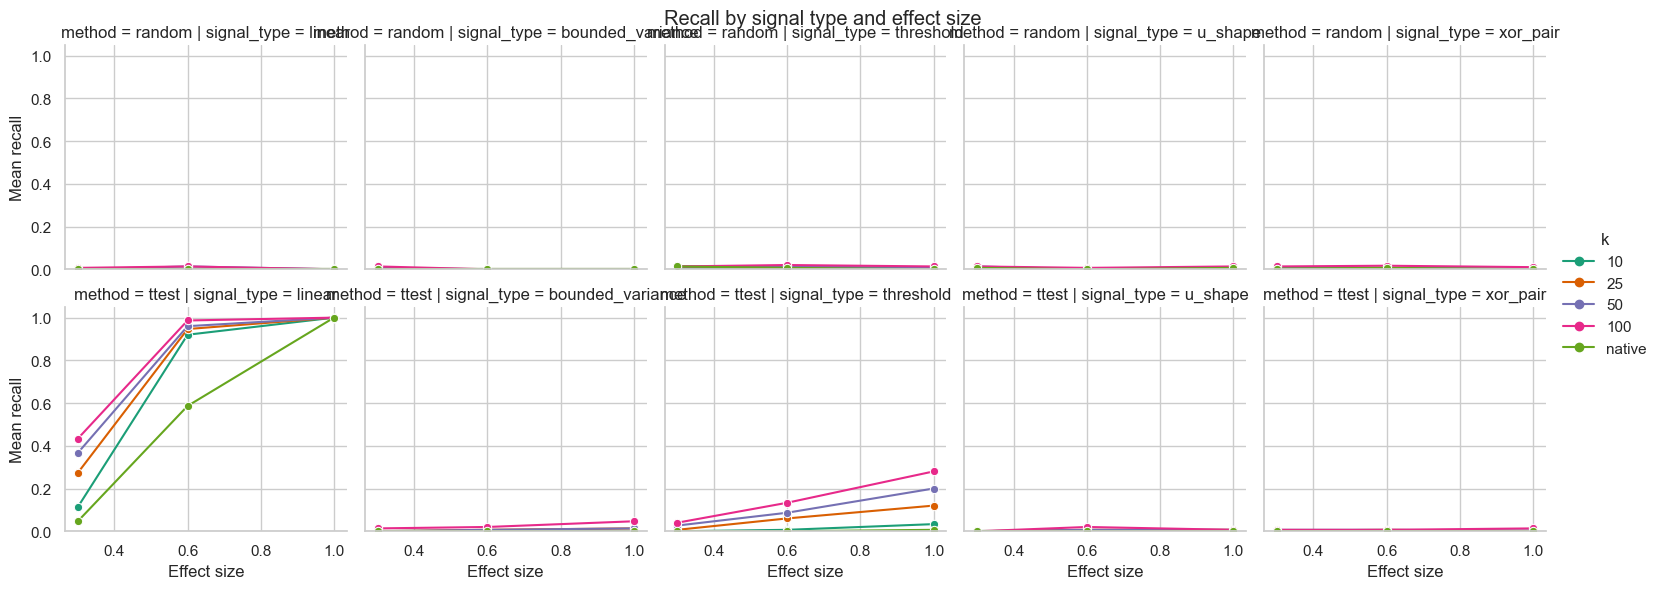

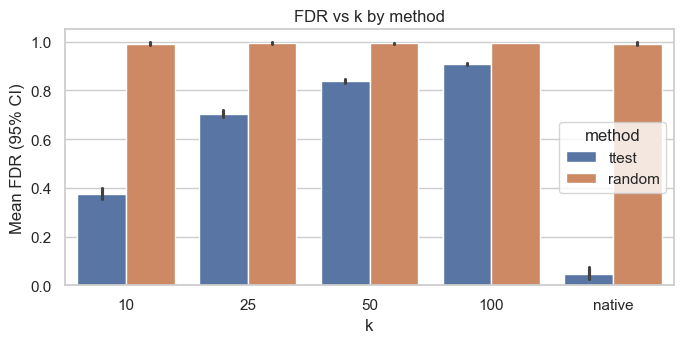

In [5]:
recall_plot_df = (
    recall_df.groupby(["method", "signal_type", "effect_size", "k"], observed=False)
    .agg(recall_mean=("recall", "mean"))
    .reset_index()
)

palette = {
    "10": "#1b9e77",
    "25": "#d95f02",
    "50": "#7570b3",
    "100": "#e7298a",
    "native": "#66a61e",
}

g_recall = sns.relplot(
    data=recall_plot_df,
    x="effect_size",
    y="recall_mean",
    hue="k",
    hue_order=k_order,
    col="signal_type",
    row="method",
    kind="line",
    marker="o",
    dashes=False,
    height=3.0,
    aspect=1.05,
    palette=palette,
)
g_recall.set(ylim=(0, 1.05))
g_recall.set_axis_labels("Effect size", "Mean recall")
g_recall.fig.subplots_adjust(top=0.92)
g_recall.fig.suptitle("Recall by signal type and effect size")
plt.show()

# FDR has no signal_type/effect_size dimension — one value per (method, k).
fig, ax = plt.subplots(figsize=(7, 3.6))
sns.barplot(
    data=fdr_df,
    x="k",
    y="fdr",
    hue="method",
    order=k_order,
    estimator="mean",
    errorbar=("ci", 95),
    ax=ax,
)
ax.set_ylim(0, 1.05)
ax.set_xlabel("k")
ax.set_ylabel("Mean FDR (95% CI)")
ax.set_title("FDR vs k by method")
fig.tight_layout()
plt.show()

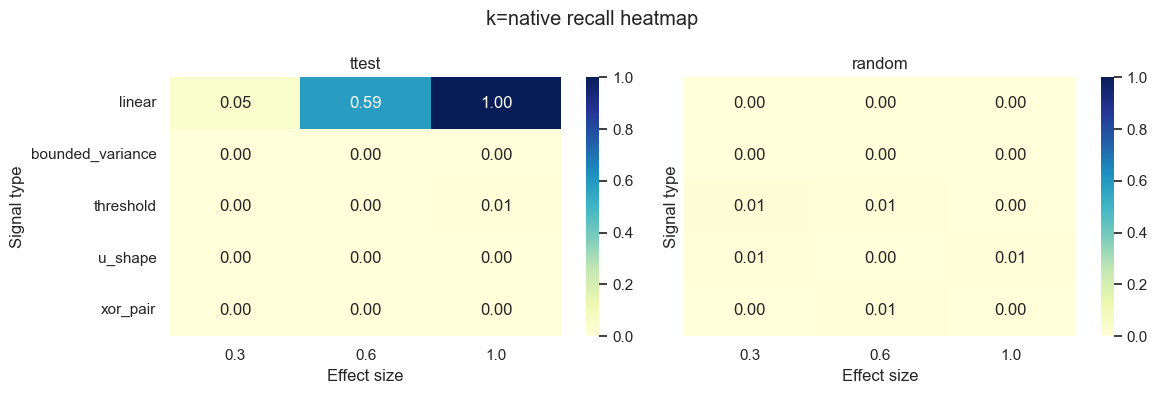

FDR per (method, k):


method,random,ttest
k,,
10,0.992,0.376
25,0.994,0.705
50,0.993,0.838
100,0.994,0.909
native,0.992,0.047


In [17]:
k = "native"
native_df = (
    recall_df[recall_df["k"] == k]
    .groupby(["method", "signal_type", "effect_size"], observed=False)
    .agg(recall_mean=("recall", "mean"))
    .reset_index()
)

fig, axes = plt.subplots(1, len(METHODS), figsize=(12, 4), sharey=True)
if len(METHODS) == 1:
    axes = [axes]

for ax, method in zip(axes, METHODS):
    matrix = (
        native_df[native_df["method"] == method]
        .pivot(index="signal_type", columns="effect_size", values="recall_mean")
        .reindex(signal_order)
    )
    sns.heatmap(
        matrix, annot=True, fmt=".2f", cmap="YlGnBu",
        vmin=0.0, vmax=1.0, cbar=True, ax=ax,
    )
    ax.set_title(f"{method}")
    ax.set_xlabel("Effect size")
    ax.set_ylabel("Signal type")

fig.suptitle(f"k={k} recall heatmap")
fig.tight_layout()
plt.show()

# Per-(method, k) FDR table — the only grain on which FDR is defined.
print("FDR per (method, k):")
display(
    fdr_summary_method_k.pivot(index="k", columns="method", values="fdr_mean").round(3)
)

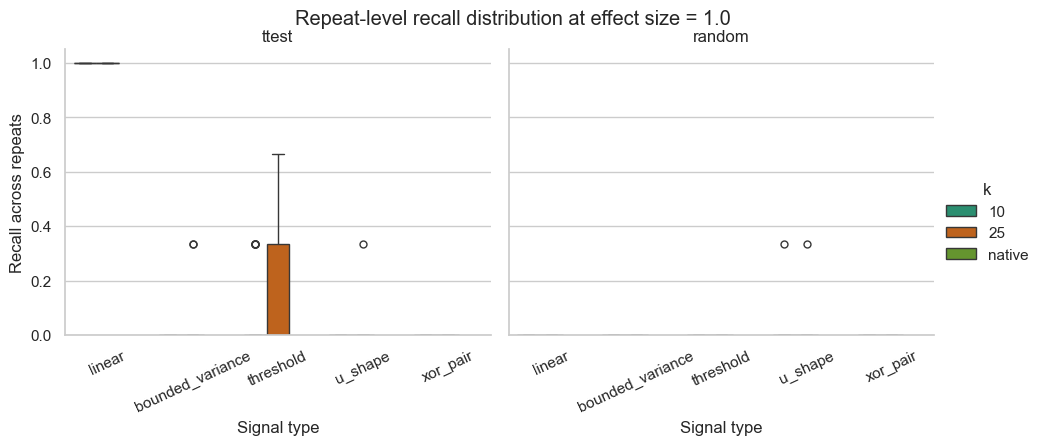

In [7]:
repeat_focus = recall_df[(recall_df["effect_size"] == 1.0) & (recall_df["k"].isin(["10", "25", "native"]))].copy()

box = sns.catplot(
    data=repeat_focus,
    x="signal_type",
    y="recall",
    hue="k",
    hue_order=["10", "25", "native"],
    col="method",
    kind="box",
    height=4,
    aspect=1.2,
    palette=palette,
)
box.set_axis_labels("Signal type", "Recall across repeats")
box.set_titles("{col_name}")
box.fig.subplots_adjust(top=0.88)
box.fig.suptitle("Repeat-level recall distribution at effect size = 1.0")
for ax in box.axes.flat:
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=25)
plt.show()

## Block-level metrics

`block_recall` counts a planted feature as found if **any feature in its block** is selected (pathway-discovery framing). `block_fdr` counts a selected feature as a false discovery only if its block contains **no** planted signal. Both metrics fall back to the strict versions when the dataset was generated with `block_size=None`.

In [8]:
if not HAS_BLOCK_RECALL:
    print("block_recall not present in any loaded parquet — re-run scripts/05_run_simulation.py to populate.")
else:
    block_recall_summary_method_k = (
        recall_df.groupby(["method", "k"], observed=False)
        .agg(
            recall_mean=("recall", "mean"),
            block_recall_mean=("block_recall", "mean"),
            block_recall_std=("block_recall", "std"),
        )
        .assign(gap=lambda d: (d["block_recall_mean"] - d["recall_mean"]).round(3))
        .reset_index()
        .round(3)
    )
    print("Block recall vs strict recall by method and k (gap = block - strict)")
    display(block_recall_summary_method_k)
    print("Block recall mean pivot (k x method)")
    display(
        block_recall_summary_method_k.pivot(
            index="k", columns="method", values="block_recall_mean"
        )
    )

Block recall vs strict recall by method and k (gap = block - strict)


,method,k,recall_mean,block_recall_mean,block_recall_std,gap
0,random,10,0.002,0.015,0.066,0.013
1,random,25,0.003,0.044,0.110,0.041
2,random,50,0.006,0.088,0.152,0.082
3,random,100,0.010,0.167,0.207,0.157
4,random,native,0.003,0.033,0.098,0.030
5,ttest,10,0.138,0.151,0.331,0.012
6,ttest,25,0.163,0.186,0.339,0.023
7,ttest,50,0.179,0.218,0.345,0.039
8,ttest,100,0.200,0.270,0.353,0.070
9,ttest,native,0.109,0.118,0.290,0.008


Block recall mean pivot (k x method)


method,random,ttest
k,,
10,0.015,0.151
25,0.044,0.186
50,0.088,0.218
100,0.167,0.270
native,0.033,0.118


In [9]:
if not HAS_BLOCK_FDR:
    print("block_fdr not present in any loaded parquet — re-run scripts/05_run_simulation.py to populate.")
else:
    block_fdr_summary_method_k = (
        fdr_df.groupby(["method", "k"], observed=False)
        .agg(
            fdr_mean=("fdr", "mean"),
            block_fdr_mean=("block_fdr", "mean"),
            block_fdr_std=("block_fdr", "std"),
            n_selected_mean=("n_selected", "mean"),
        )
        .assign(gap=lambda d: (d["fdr_mean"] - d["block_fdr_mean"]).round(3))
        .reset_index()
        .round(3)
    )
    print("Block FDR vs strict FDR by method and k (gap = strict - block)")
    display(block_fdr_summary_method_k)
    print("Block FDR mean pivot (k x method)")
    display(
        block_fdr_summary_method_k.pivot(
            index="k", columns="method", values="block_fdr_mean"
        )
    )

Block FDR vs strict FDR by method and k (gap = strict - block)


,method,k,fdr_mean,block_fdr_mean,block_fdr_std,n_selected_mean,gap
0,random,10,0.992,0.924,0.082,10.00,0.068
1,random,25,0.994,0.910,0.048,25.00,0.084
2,random,50,0.993,0.906,0.036,50.00,0.087
3,random,100,0.994,0.906,0.026,100.00,0.088
4,random,native,0.992,0.914,0.053,20.00,0.078
5,ttest,10,0.376,0.346,0.093,10.00,0.030
6,ttest,25,0.705,0.647,0.085,25.00,0.058
7,ttest,50,0.838,0.768,0.074,50.00,0.069
8,ttest,100,0.909,0.833,0.059,100.00,0.076
9,ttest,native,0.047,0.041,0.084,5.22,0.006


Block FDR mean pivot (k x method)


method,random,ttest
k,,
10,0.924,0.346
25,0.910,0.647
50,0.906,0.768
100,0.906,0.833
native,0.914,0.041


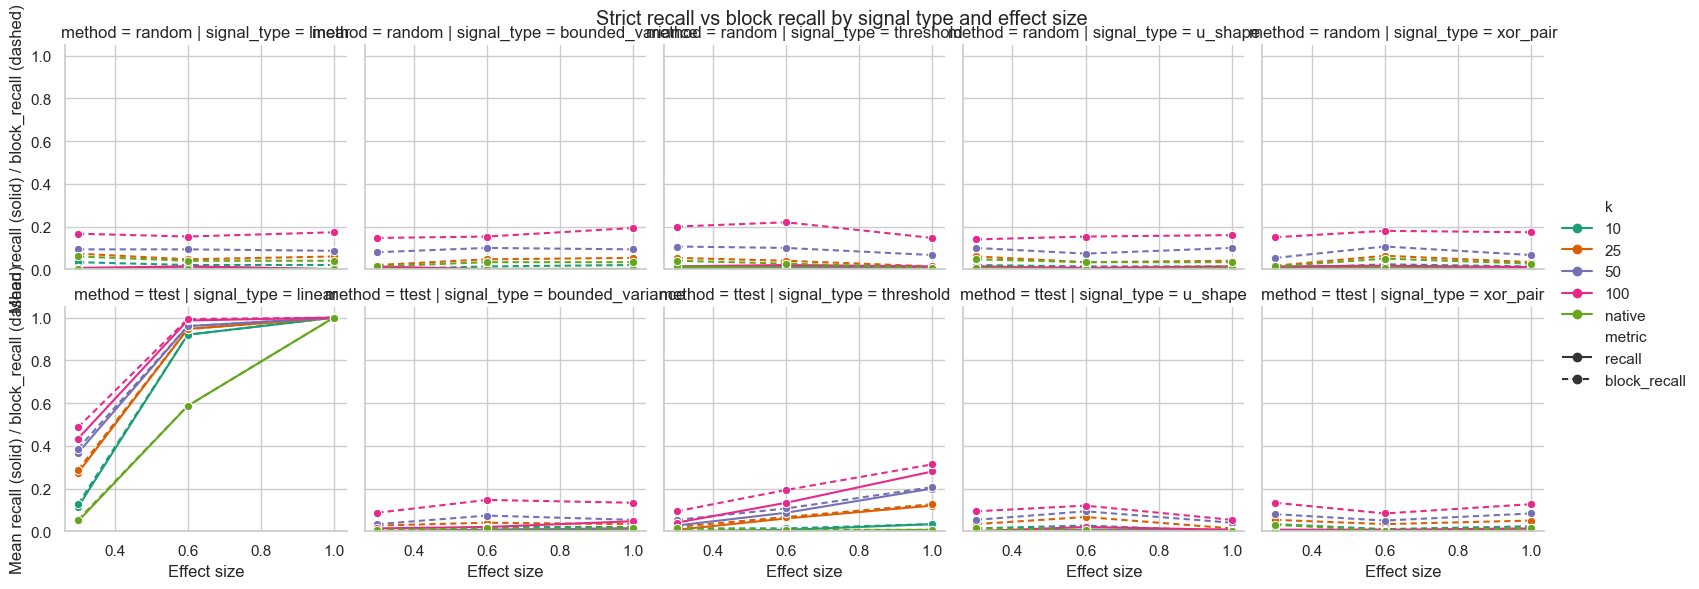

In [10]:
if HAS_BLOCK_RECALL:
    long_recall = (
        recall_df
        .melt(
            id_vars=["method", "signal_type", "effect_size", "k"],
            value_vars=["recall", "block_recall"],
            var_name="metric",
            value_name="value",
        )
        .groupby(["method", "signal_type", "effect_size", "k", "metric"], observed=False)
        .agg(value_mean=("value", "mean"))
        .reset_index()
    )

    g_block = sns.relplot(
        data=long_recall,
        x="effect_size",
        y="value_mean",
        hue="k",
        hue_order=k_order,
        style="metric",
        style_order=["recall", "block_recall"],
        col="signal_type",
        row="method",
        kind="line",
        marker="o",
        dashes={"recall": (1, 0), "block_recall": (3, 2)},
        height=3.0,
        aspect=1.05,
        palette=palette,
    )
    g_block.set(ylim=(0, 1.05))
    g_block.set_axis_labels("Effect size", "Mean recall (solid) / block_recall (dashed)")
    g_block.fig.subplots_adjust(top=0.92)
    g_block.fig.suptitle("Strict recall vs block recall by signal type and effect size")
    plt.show()
else:
    print("Skipping recall vs block_recall plot: block_recall not populated.")

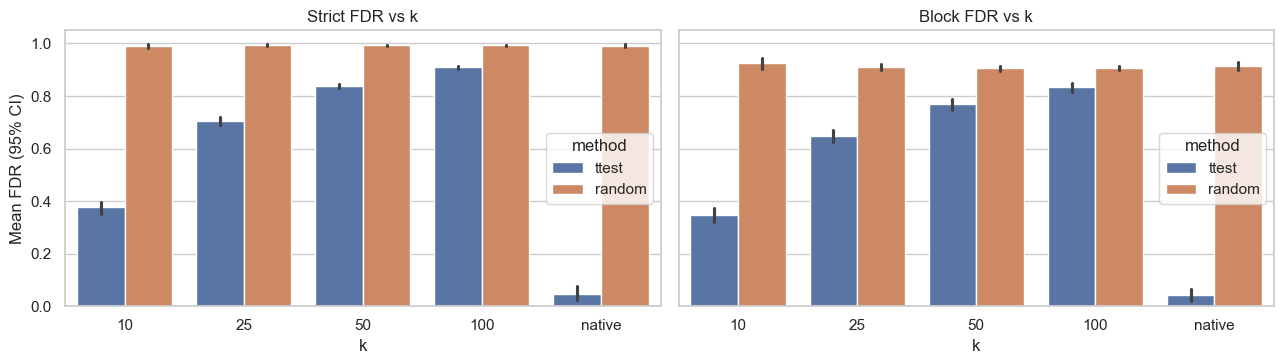

In [11]:
if HAS_BLOCK_FDR:
    long_fdr = fdr_df.melt(
        id_vars=["method", "k"],
        value_vars=["fdr", "block_fdr"],
        var_name="metric",
        value_name="value",
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
    sns.barplot(
        data=long_fdr[long_fdr["metric"] == "fdr"],
        x="k", y="value", hue="method", order=k_order,
        estimator="mean", errorbar=("ci", 95), ax=axes[0],
    )
    axes[0].set_title("Strict FDR vs k")
    axes[0].set_ylabel("Mean FDR (95% CI)")
    axes[0].set_xlabel("k")

    sns.barplot(
        data=long_fdr[long_fdr["metric"] == "block_fdr"],
        x="k", y="value", hue="method", order=k_order,
        estimator="mean", errorbar=("ci", 95), ax=axes[1],
    )
    axes[1].set_title("Block FDR vs k")
    axes[1].set_ylabel("")
    axes[1].set_xlabel("k")

    for ax in axes:
        ax.set_ylim(0, 1.05)

    fig.tight_layout()
    plt.show()
else:
    print("Skipping FDR vs block_fdr plot: block_fdr not populated.")